In [5]:
import numpy as np
from hierarchical_clustering import AgglomerativeClustering
from utils import *
from find_best_K import *
import warnings
import matplotlib.pyplot as plt
from collections import Counter

In [8]:
n=30
total_alpha = 0.05
X = generate_3cluster_data(n,10,5)[0]
alpha_list = generate_alpha_list(n=n,total_alpha=total_alpha)
num_trials = 100
Ks = []
for _ in range(num_trials):
    K,_,_ = find_best_K_F(X, tau=1, alpha_list=alpha_list)
    Ks.append(K)

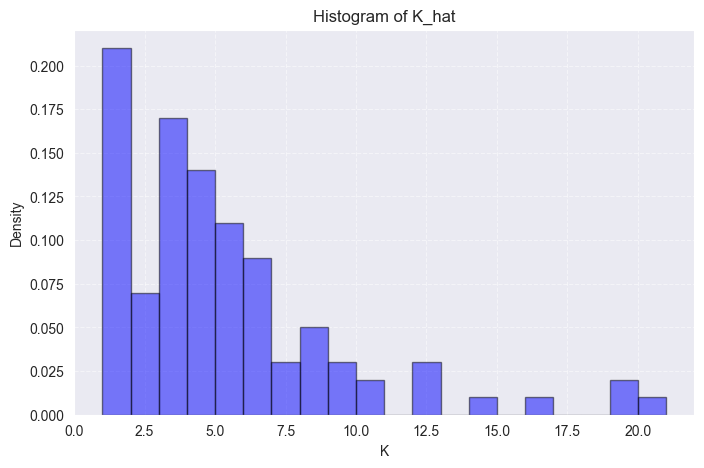

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(Ks, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="K hat")
plt.xlabel("K")
plt.ylabel("Density")
plt.title("Histogram of K_hat")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [10]:
counter = Counter(Ks)
counter.most_common

<bound method Counter.most_common of Counter({1: 21, 3: 17, 4: 14, 5: 11, 6: 9, 2: 7, 8: 5, 9: 3, 12: 3, 7: 3, 19: 2, 10: 2, 14: 1, 16: 1, 21: 1})>

In [11]:
n=30
total_alpha = 0.05
X = generate_3cluster_data(n,10,10)[0]
alpha_list = generate_alpha_list(n=n,total_alpha=total_alpha)
num_trials = 100
Ks = []
for _ in range(num_trials):
    K,_,_ = find_best_K_F(X, tau=1, alpha_list=alpha_list)
    Ks.append(K)

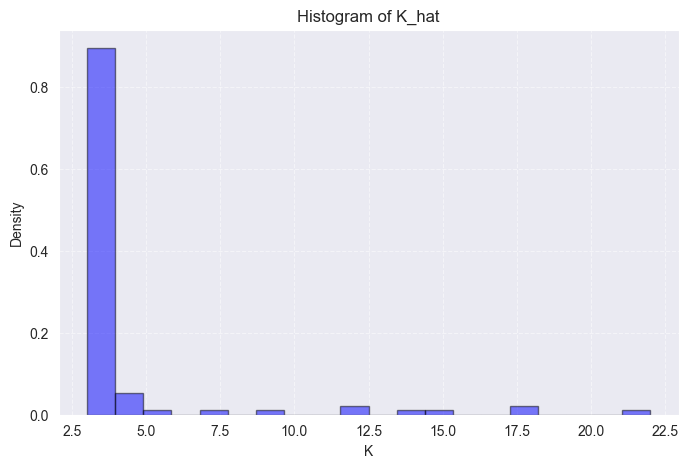

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(Ks, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="K hat")
plt.xlabel("K")
plt.ylabel("Density")
plt.title("Histogram of K_hat")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [13]:
counter = Counter(Ks)
counter.most_common

<bound method Counter.most_common of Counter({3: 85, 4: 5, 12: 2, 18: 2, 14: 1, 22: 1, 5: 1, 15: 1, 7: 1, 9: 1})>

In [2]:
def generate_alpha_list(seed=42):
    np.random.seed(seed)

    # Define size per group
    n_large = 10
    n_medium = 10
    n_small = 9

    # Generate unnormalized values in each group
    large = np.random.uniform(0.003, 0.008, size=n_large)
    medium = np.random.uniform(0.001, 0.003, size=n_medium)
    small = np.random.uniform(1e-5, 5e-4, size=n_small)

    # Combine and normalize
    alpha_raw = np.concatenate([large, medium, small])
    alpha_list = 0.05 * alpha_raw / np.sum(alpha_raw)

    return alpha_list

In [7]:
def find_best_K_F(X, tau,alpha_list, n_threshold = 2, linkage = "complete", total_alpha=0.05):
    n = np.shape(X)[0]
    if not np.isclose(np.sum(alpha_list), total_alpha):
        raise ValueError(f"Alpha list should sum up to total alpha = {total_alpha}, " f"but got {np.sum(alpha_list):.4f} instead.")
    if len(alpha_list) != (n-1):
        raise ValueError("The length of alpha_list should be equal to n - 1.")
    
    p_values = []
    alpha_seq = []
    K_hat = 1
    
    model = AgglomerativeClustering(X, tau=tau, n_clusters=1,linkage=linkage)
    model.fit()
    winning_nodes = list(model.existing_clusters_log.keys()) #to get all merges
    for t in range(len(winning_nodes)):
        winning_pair = winning_nodes[t]
        node1 = winning_pair[0]
        node2 = winning_pair[1]
        node = node1.parent
        n1 = len(node1.points)
        n2 = len(node2.points)
        if (1/n1 + 1/n2) >= n_threshold:
            alpha = np.min(alpha_list) #more conservative for smaller clusters
            idx = np.argmin(alpha_list)
            
            if (n1+n2) == 2:
                pval = 1 #F distribution method cannot handle the case when n1+n2=2
            else:
                pval,_,_ = model.merge_inference_F(node, grid_width=50, ncoarse=20, ngrid=1000)
            
        else:
            alpha = np.max(alpha_list) # More power for larger clusters
            idx = np.argmax(alpha_list)
            pval,_,_ = model.merge_inference_F(node, grid_width=50, ncoarse=20, ngrid=1000)
        alpha_list = np.delete(alpha_list,idx)
        alpha_seq.append(alpha)
        p_values.append(pval)
        if pval<alpha:
            K_hat = n-t
            return(K_hat, p_values,alpha_seq)
    return(K_hat, p_values,alpha_seq)
            

In [4]:
def find_best_K_chi(X, tau,alpha_list, n_threshold = 2, linkage = "complete", total_alpha=0.05):
    n = np.shape(X)[0]
    if not np.isclose(np.sum(alpha_list), total_alpha):
        raise ValueError(f"Alpha list should sum up to total alpha = {total_alpha}, " f"but got {np.sum(alpha_list):.4f} instead.")
    if len(alpha_list) != (n-1):
        raise ValueError("The length of alpha_list should be equal to n - 1.")
    
    p_values = []
    alpha_seq = []
    K_hat = 1
    
    model = AgglomerativeClustering(X, tau=tau, n_clusters=1,linkage=linkage)
    model.fit()
    winning_nodes = list(model.existing_clusters_log.keys()) #to get all merges
    for t in range(len(winning_nodes)):
        winning_pair = winning_nodes[t]
        node1 = winning_pair[0]
        node2 = winning_pair[1]
        node = node1.parent
        n1 = len(node1.points)
        n2 = len(node2.points)
        if (1/n1 + 1/n2) >= n_threshold:
            alpha = np.min(alpha_list) #more conservative for smaller clusters
            idx = np.argmin(alpha_list)
            '''
            if (n1+n2) == 2:
                pval = 1 #F distribution method cannot handle the case when n1+n2=2
            else:
                pval,_,_ = model.merge_inference_F(node, grid_width=50, ncoarse=20, ngrid=1000)
            '''
        else:
            alpha = np.max(alpha_list) # More power for larger clusters
            idx = np.argmax(alpha_list)
        pval,_,_ = model.merge_inference_chi(node, grid_width=50, ncoarse=20, ngrid=1000)
        alpha_list = np.delete(alpha_list,idx)
        alpha_seq.append(alpha)
        p_values.append(pval)
        if pval<alpha:
            K_hat = n-t
            return(K_hat, p_values,alpha_seq)
    return(K_hat, p_values,alpha_seq)
            

In [82]:
X = generate_3cluster_data(30,2,10)[0]
alpha_list = generate_alpha_list()
num_trials = 30
Ks = []
for _ in range(num_trials):
    K,_,_ = find_best_K_chi(X, tau=1, alpha_list=alpha_list)
    Ks.append(K)

level:  1
level:  2
level:  1
level:  3
level:  2
level:  1
level:  4
level:  3
level:  2
level:  1
level:  5
level:  4
level:  3
level:  2
level:  1
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level

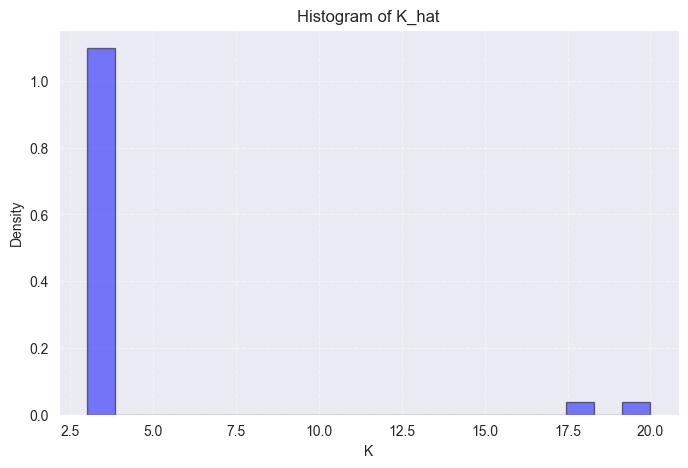

In [83]:
plt.figure(figsize=(8, 5))
plt.hist(Ks, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="K hat")
plt.xlabel("K")
plt.ylabel("Density")
plt.title("Histogram of K_hat")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [84]:
from collections import Counter
counter = Counter(Ks)
most_freq = counter.most_common(1)[0][0]
print(most_freq) 

3


In [12]:
X = generate_3cluster_data(30,2,5)[0]
alpha_list = generate_alpha_list()
num_trials = 30
Ks = []
for _ in range(num_trials):
    K,_,_ = find_best_K_F(X, tau=1, alpha_list=alpha_list)
    Ks.append(K)

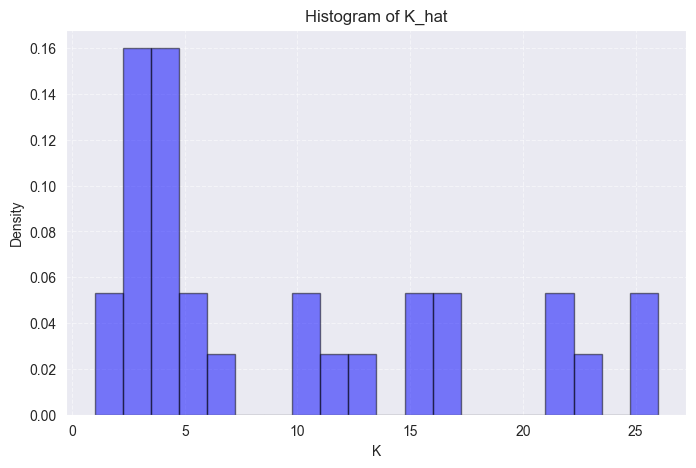

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(Ks, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="K hat")
plt.xlabel("K")
plt.ylabel("Density")
plt.title("Histogram of K_hat")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [17]:
from collections import Counter
counter = Counter(Ks)
counter.most_common


<bound method Counter.most_common of Counter({4: 6, 3: 6, 5: 2, 15: 2, 21: 2, 10: 2, 1: 2, 26: 2, 23: 1, 7: 1, 17: 1, 13: 1, 11: 1, 16: 1})>

In [16]:
counter.most_common

<bound method Counter.most_common of Counter({4: 6, 3: 6, 5: 2, 15: 2, 21: 2, 10: 2, 1: 2, 26: 2, 23: 1, 7: 1, 17: 1, 13: 1, 11: 1, 16: 1})>